# Human Brain Analysis
Last Updated: 06-18-2026
Datasets: Ping et al., Nature 2018

# Directories, Dependencies, Helper Functions, & Data Pre-processing

In [284]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg


print("packages have been successfully read in!")

packages have been successfully read in!


In [285]:
# #Setting directories and reading in data
# #Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample

# print("loading directories...")
# CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
# PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
# INDIR           = PROJ_DIR + 'Analysis_Inputs/Ping_2018/'
# OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Ping_2018/'
# DEPDIR          = CODE_DIR + 'Dependencies/Ping_2018/'
# MQ_DIR          = PROJ_DIR + 'mq_output/Ping_2018/'
# PLOT_DIR        = PROJ_DIR + 'Plots/Ping_2018/'
# SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
# SUPP_DIR        = PROJ_DIR + '/Supplementary_Tables/'

# os.makedirs(OUTDIR, exist_ok=True)
# os.makedirs(PLOT_DIR, exist_ok=True)

# ## ANTERIOR CINGULATE GYRUS
# # B1
# acgb1_proj_dir      = OUTDIR + 'acg/b1/'
# acgb1_aa_subs_dir   = INDIR + 'acg/b1/'
# acgb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb1.xlsx')
# acgb1_samples       = ['S'+str(i) for i in list(set(acgb1_sample_map['TMT plex']))]
# acgb1_mq            = MQ_DIR + 'acg/b1/'

# # B2
# acgb2_proj_dir      = OUTDIR + 'acg/b2/'
# acgb2_aa_subs_dir   = INDIR + 'acg/b2/'
# acgb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb2.xlsx')
# acgb2_samples       = ['S'+str(i) for i in list(set(acgb2_sample_map['TMT plex']))]
# acgb2_mq            = MQ_DIR + 'acg/b2/'

# # B3
# acgb3_proj_dir      = OUTDIR + 'acg/b3/'
# acgb3_aa_subs_dir   = INDIR + 'acg/b3/'
# acgb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb3.xlsx')
# acgb3_samples       = ['S'+str(i) for i in list(set(acgb3_sample_map['TMT plex']))]
# acgb3_mq            = MQ_DIR + 'acg/b3/'

# # B4
# acgb4_proj_dir      = OUTDIR + 'acg/b4/'
# acgb4_aa_subs_dir   = INDIR + 'acg/b4/'
# acgb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb4.xlsx')
# acgb4_samples       = ['S'+str(i) for i in list(set(acgb4_sample_map['TMT plex']))]
# acgb4_mq            = MQ_DIR + 'acg/b4/'

# # B5
# acgb5_proj_dir      = OUTDIR + 'acg/b5/'
# acgb5_aa_subs_dir   = INDIR + 'acg/b5/'
# acgb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb5.xlsx')
# acgb5_samples       = ['S'+str(i) for i in list(set(acgb5_sample_map['TMT plex']))]
# acgb5_mq            = MQ_DIR + 'acg/b5/'


# ## FRONTAL CORTEX
# # B1
# fcb1_proj_dir      = OUTDIR + 'fc/b1/'
# fcb1_aa_subs_dir   = INDIR + 'fc/b1/'
# fcb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb1.xlsx')
# fcb1_samples       = ['S'+str(i) for i in list(set(fcb1_sample_map['TMT plex']))]
# fcb1_mq            = MQ_DIR + 'fc/b1/'

# # B2
# fcb2_proj_dir      = OUTDIR + 'fc/b2/'
# fcb2_aa_subs_dir   = INDIR + 'fc/b2/'
# fcb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb2.xlsx')
# fcb2_samples       = ['S'+str(i) for i in list(set(fcb2_sample_map['TMT plex']))]
# fcb2_mq            = MQ_DIR + 'fc/b2/'

# # B3
# fcb3_proj_dir      = OUTDIR + 'fc/b3/'
# fcb3_aa_subs_dir   = INDIR + 'fc/b3/'
# fcb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb3.xlsx')
# fcb3_samples       = ['S'+str(i) for i in list(set(fcb3_sample_map['TMT plex']))]
# fcb3_mq            = MQ_DIR + 'fc/b3/'

# # B4
# fcb4_proj_dir      = OUTDIR + 'fc/b4/'
# fcb4_aa_subs_dir   = INDIR + 'fc/b4/'
# fcb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb4.xlsx')
# fcb4_samples       = ['S'+str(i) for i in list(set(fcb4_sample_map['TMT plex']))]
# fcb4_mq            = MQ_DIR + 'fc/b4/'

# # B5
# fcb5_proj_dir      = OUTDIR + 'fc/b5/'
# fcb5_aa_subs_dir   = INDIR + 'fc/b5/'
# fcb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb5.xlsx')
# fcb5_samples       = ['S'+str(i) for i in list(set(fcb5_sample_map['TMT plex']))]
# fcb5_mq            = MQ_DIR + 'fc/b5/'


# #lists to quickly index dataset-specific sample maps from just the dataset name
# datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb1', 'fcb2', 'fcb3', 'fcb4', 'fcb5']
# acg_datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5']
# fc_datasets = ['fcb1','fcb2','fcb3','fcb4','fcb5']

# data_dir_list = [acgb1_aa_subs_dir, acgb2_aa_subs_dir, acgb3_aa_subs_dir, acgb4_aa_subs_dir, acgb5_aa_subs_dir, fcb1_aa_subs_dir, fcb2_aa_subs_dir, fcb3_aa_subs_dir, fcb4_aa_subs_dir, fcb5_aa_subs_dir]
# proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir, fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]
# acg_proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir]
# fc_proj_dir_list = [fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]

# samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples, fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]
# sample_map_list = [acgb1_sample_map, acgb2_sample_map, acgb3_sample_map, acgb4_sample_map, acgb5_sample_map, fcb1_sample_map, fcb2_sample_map, fcb3_sample_map, fcb4_sample_map, fcb5_sample_map]
# acg_samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples]
# fc_samples_list = [fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]

# mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq, fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]
# acg_mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq]
# fc_mq_dir_list = [fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]

# print("directories loaded successfully!")

In [286]:
#Setting directories and reading in data
#Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Ping_2018/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Ping_2018/'
DEPDIR          = CODE_DIR + 'Dependencies/Ping_2018/'
MQ_DIR          = PROJ_DIR + 'frag_output/Ping_2018/'   # FragPipe: <region>/<batch>/<plex>_1/ holds psm.tsv + per-fraction *.tsv
PLOT_DIR        = PROJ_DIR + 'Plots/Ping_2018/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + '/Supplementary_Tables/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## ANTERIOR CINGULATE GYRUS
# B1
acgb1_proj_dir      = OUTDIR + 'acg/b1/'
acgb1_aa_subs_dir   = INDIR + 'acg/b1/'
acgb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb1.xlsx')
acgb1_samples       = ['S'+str(i) for i in list(set(acgb1_sample_map['TMT plex']))]
acgb1_mq            = MQ_DIR + 'acg/b1/acgb1_1/'

# B2
acgb2_proj_dir      = OUTDIR + 'acg/b2/'
acgb2_aa_subs_dir   = INDIR + 'acg/b2/'
acgb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb2.xlsx')
acgb2_samples       = ['S'+str(i) for i in list(set(acgb2_sample_map['TMT plex']))]
acgb2_mq            = MQ_DIR + 'acg/b2/acgb2_1/'

# B3
acgb3_proj_dir      = OUTDIR + 'acg/b3/'
acgb3_aa_subs_dir   = INDIR + 'acg/b3/'
acgb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb3.xlsx')
acgb3_samples       = ['S'+str(i) for i in list(set(acgb3_sample_map['TMT plex']))]
acgb3_mq            = MQ_DIR + 'acg/b3/acgb3_1/'

# B4
acgb4_proj_dir      = OUTDIR + 'acg/b4/'
acgb4_aa_subs_dir   = INDIR + 'acg/b4/'
acgb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb4.xlsx')
acgb4_samples       = ['S'+str(i) for i in list(set(acgb4_sample_map['TMT plex']))]
acgb4_mq            = MQ_DIR + 'acg/b4/acgb4_1/'

# B5
acgb5_proj_dir      = OUTDIR + 'acg/b5/'
acgb5_aa_subs_dir   = INDIR + 'acg/b5/'
acgb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb5.xlsx')
acgb5_samples       = ['S'+str(i) for i in list(set(acgb5_sample_map['TMT plex']))]
acgb5_mq            = MQ_DIR + 'acg/b5/acgb5_1/'


## FRONTAL CORTEX
# B1
fcb1_proj_dir      = OUTDIR + 'fc/b1/'
fcb1_aa_subs_dir   = INDIR + 'fc/b1/'
fcb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb1.xlsx')
fcb1_samples       = ['S'+str(i) for i in list(set(fcb1_sample_map['TMT plex']))]
fcb1_mq            = MQ_DIR + 'fc/b1/fcb1_1/'

# B2
fcb2_proj_dir      = OUTDIR + 'fc/b2/'
fcb2_aa_subs_dir   = INDIR + 'fc/b2/'
fcb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb2.xlsx')
fcb2_samples       = ['S'+str(i) for i in list(set(fcb2_sample_map['TMT plex']))]
fcb2_mq            = MQ_DIR + 'fc/b2/fcb2_1/'

# B3
fcb3_proj_dir      = OUTDIR + 'fc/b3/'
fcb3_aa_subs_dir   = INDIR + 'fc/b3/'
fcb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb3.xlsx')
fcb3_samples       = ['S'+str(i) for i in list(set(fcb3_sample_map['TMT plex']))]
fcb3_mq            = MQ_DIR + 'fc/b3/fcb3_1/'

# B4
fcb4_proj_dir      = OUTDIR + 'fc/b4/'
fcb4_aa_subs_dir   = INDIR + 'fc/b4/'
fcb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb4.xlsx')
fcb4_samples       = ['S'+str(i) for i in list(set(fcb4_sample_map['TMT plex']))]
fcb4_mq            = MQ_DIR + 'fc/b4/fcb4_1/'

# B5
fcb5_proj_dir      = OUTDIR + 'fc/b5/'
fcb5_aa_subs_dir   = INDIR + 'fc/b5/'
fcb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb5.xlsx')
fcb5_samples       = ['S'+str(i) for i in list(set(fcb5_sample_map['TMT plex']))]
fcb5_mq            = MQ_DIR + 'fc/b5/fcb5_1/'


#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb1', 'fcb2', 'fcb3', 'fcb4', 'fcb5']
acg_datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5']
fc_datasets = ['fcb1','fcb2','fcb3','fcb4','fcb5']

data_dir_list = [acgb1_aa_subs_dir, acgb2_aa_subs_dir, acgb3_aa_subs_dir, acgb4_aa_subs_dir, acgb5_aa_subs_dir, fcb1_aa_subs_dir, fcb2_aa_subs_dir, fcb3_aa_subs_dir, fcb4_aa_subs_dir, fcb5_aa_subs_dir]
proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir, fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]
acg_proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir]
fc_proj_dir_list = [fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]

samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples, fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]
sample_map_list = [acgb1_sample_map, acgb2_sample_map, acgb3_sample_map, acgb4_sample_map, acgb5_sample_map, fcb1_sample_map, fcb2_sample_map, fcb3_sample_map, fcb4_sample_map, fcb5_sample_map]
acg_samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples]
fc_samples_list = [fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]

mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq, fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]
acg_mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq]
fc_mq_dir_list = [fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]

print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [287]:
""" 
Read in data generated from dependencies code
if dependencies have not been generated, go back and generate
To analyze FC and ACG tissues together, must compile dataframes 
""" 

## Fragment data
# Positional probability fragment ion data
pos_prob_df_acg = pd.read_csv(DEPDIR+'acg/Position_probability_fragment_ion_data.csv')
pos_prob_df_fc = pd.read_csv(DEPDIR+'fc/Position_probability_fragment_ion_data.csv')
pos_prob_df = pd.concat([pos_prob_df_acg, pos_prob_df_fc])

frag_dict_acg = pickle.load(open(DEPDIR+'acg/Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
frag_dict_fc = pickle.load(open(DEPDIR+'fc/Fragment_ion_dict.p', 'rb'))
frag_dict = {
    'acg': frag_dict_acg,
    'fc': frag_dict_fc}

# Fragment ions per SAAP
frag_df_acg = pd.read_excel(DEPDIR+'acg/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df_fc = pd.read_excel(DEPDIR+'fc/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df = pd.concat([frag_df_acg,frag_df_fc])

## Dataset metrics
ds_metrics_acg = pd.read_excel(DEPDIR+'acg/dataset_metrics.xlsx')
ds_metrics_fc = pd.read_excel(DEPDIR+'fc/dataset_metrics.xlsx')
ds_metrics = pd.concat([ds_metrics_acg, ds_metrics_fc])
# print(ds_metrics)

## SAAP quantification dataframe (contains RAAS) & Preprocessing
SAAP_quant_df_acg = pd.read_excel(DEPDIR+'acg/SAAP_precursor_reporter_quant.xlsx')
SAAP_quant_df_acg = SAAP_quant_df_acg[SAAP_quant_df_acg['Sample Type'] != 'Unknown']
SAAP_quant_df_acg_list = [SAAP_quant_df_acg.loc[SAAP_quant_df_acg['Dataset']==ds] for ds in datasets]

SAAP_quant_df_fc = pd.read_excel(DEPDIR+'fc/SAAP_precursor_reporter_quant.xlsx')
SAAP_quant_df_fc = SAAP_quant_df_fc[SAAP_quant_df_fc['Sample Type'] != 'Unknown']
SAAP_quant_df_fc_list = [SAAP_quant_df_fc.loc[SAAP_quant_df_fc['Dataset']==ds] for ds in datasets]

# Combine ACG and FC dataframes to build SAAP_quant_df
SAAP_quant_df_list = [SAAP_quant_df_acg, SAAP_quant_df_fc]
SAAP_quant_df = pd.concat([SAAP_quant_df_acg, SAAP_quant_df_fc])
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['Sample Type'] != 'Unknown'] # filter out GIS
print(SAAP_quant_df)


      Row Number Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0              0   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
1              1   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
2              2   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
3              3   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
4              4   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
...          ...     ...             ...             ...     ...     ...   
4014        4014    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
4015        4015    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
4016        4016    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
4017        4017    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
4018        4018    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   

      Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  ...  \
0           

In [288]:
# Save as Supplemental_Data_1.SAAP_precursor_reporter_quant_neurodegenerative.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_1.SAAP_precursor_reporter_quant_neurodegenerative.xlsx',sheet_name='Users',index=True)

## Data Pre-processing

### a. Assess data completeness

In [289]:
# Assess data completeness of SAAPs in SAAP_quant_df 
print(f'{len(SAAP_quant_df):,} total SAAP observations in original dataset')
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% original dataset completeness')

# Option to replace read-in SAAP_quant_df with SAAP_quant_df that has 100% data completeness
# SAAP_quant_df = SAAP_quant_complete_df 

10,376 total SAAP observations in original dataset
8,714 fully complete SAAP observations retained
83.98% original dataset completeness


  Dataset  Completeness
0   acgb1     96.937596
1   acgb2     97.865158
2   acgb3     97.935606
3   acgb4     96.948506
4   acgb5     96.947844
5    fcb1     97.110940
6    fcb2     95.545455
7    fcb3     95.400433
8    fcb4     95.523715
9    fcb5     96.918706


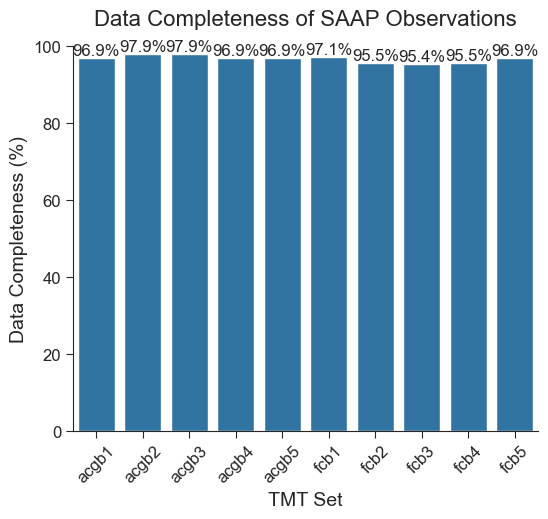

In [290]:
# Plot data completeness per tissue/TMT set 
comp_cols=['Positional_probability','SAAP_PEP','BP_PEP','MTP_PrecInt','BP_PrecInt','Prec_RAAS','MTP_ReportInt','BP_ReportInt','Reporter_RAAS','BP_ReportInt_Norm','MTP_ReportInt_Norm']

comp_df = SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df = comp_df[comp_df['Dataset']==ds]
    total_val = len(ds_df)*len(comp_cols)
    nonmissing_val = sum(ds_df[c].notna().sum() for c in comp_cols)
    completeness = 100*(nonmissing_val/total_val)
    plot_rows.append({'Dataset': ds, 'Completeness': completeness})

plot_df = pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
print(plot_df)

fig,ax = plt.subplots(figsize=(6,5))
sns.set_style('ticks')
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color='#1f78b4',ax=ax)
ax.tick_params('both',labelsize=12,length=5)
ax.tick_params(axis='x',rotation=45)
plt.xlabel('TMT Set',fontsize=14)
plt.ylabel('Data Completeness (%)',fontsize=14)
plt.ylim(0,100) 
plt.title('Data Completeness of SAAP Observations',fontsize=16,pad=15)
sns.despine()

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',label_type='edge',fontsize=12)

plt.savefig(PLOT_DIR + 'SAAP_data_completeness.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR + 'SAAP_data_completeness.png',dpi=600,bbox_inches='tight')

### b. Remove immunoglobulins and trypsin mapping SAAPs 

In [291]:
"""
Assign each SAAP a source protein/gene from FragPipe psm.tsv & drop Ig/trypsin/unresolved

1. Each SAAP (MTP_seq) is a substituted peptide that exists only in the synthetic search
space, so its parent protein is read off the BASE peptide (BP_seq) — the reference
sequence matched in that SAAP's OWN tissue (Dataset) FragPipe psm.tsv.
2. Gene symbols and protein descriptions come directly from psm.tsv columns
('Gene', 'Protein Description'), keyed by canonical accession ('Protein ID').
3. SAAPs are dropped if their base peptide maps to an immunoglobulin chain, to trypsin,
or to no NAMED protein (no gene and no description), before any downstream QC.

NOTE: resolution is keyed by (Dataset, BP_seq) so a base peptide observed in multiple
tissues is matched only against its own tissue's psm.tsv.
"""

# keep only the lead (razor) accession per base peptide. In FragPipe psm.tsv the
# 'Protein ID' column IS already the lead protein, so this is the default behavior;
# the rest of the protein group lives in 'Mapped Proteins'.
LEAD_ACCESSION_ONLY = True

def canon(acc):
    """Canonical accession: drop CON__ prefix and isoform (-2) suffix."""
    return acc.replace('CON__', '').split('-')[0]

# accession -> (gene, description) read directly from each plex's psm.tsv columns.
# psm.tsv resolves gene/description per PSM, so no FASTA-header parsing is needed.
acc_gene, acc_desc = {}, {}
for mq_dir in mq_dir_list:
    cols = ['Protein ID', 'Gene', 'Protein Description', 'Mapped Proteins', 'Mapped Genes']
    psm = pd.read_csv(mq_dir + 'psm.tsv', sep='\t', low_memory=False,
                      usecols=lambda c: c in cols)
    for acc, gene, desc in zip(psm['Protein ID'], psm.get('Gene', ''), psm.get('Protein Description', '')):
        a = canon(str(acc))
        if pd.notna(desc) and str(desc).strip():
            acc_desc.setdefault(a, str(desc).strip())
        if pd.notna(gene) and str(gene).strip():
            acc_gene.setdefault(a, str(gene).strip())
print(f'{len(acc_desc):,} reference proteins parsed from psm.tsv')

# (dataset, peptide sequence) -> FragPipe lead protein, indexed PER TISSUE so a base
# peptide shared across tissues resolves against its own tissue's psm.tsv.
# Also capture 'Mapped Proteins' so the full group is available when LEAD_ACCESSION_ONLY is False.
seq_to_proteins = {}
for dataset, mq_dir in zip(datasets, mq_dir_list):
    cols = ['Peptide', 'Protein', 'Mapped Proteins']
    psm = pd.read_csv(mq_dir + 'psm.tsv', sep='\t', low_memory=False,
                      usecols=lambda c: c in cols)
    for seq, prot, mapped in zip(psm['Peptide'], psm['Protein'].astype(str),
                                 psm.get('Mapped Proteins', pd.Series('')).astype(str)):
        if prot and prot != 'nan':
            # join lead + mapped into one ';'-style string, mirroring MaxQuant 'Proteins'
            full = prot if mapped in ('', 'nan') else prot + ';' + mapped.replace(', ', ';')
            seq_to_proteins.setdefault((dataset, seq), full)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(mq_dir_list)} psm.tsv files')

def proteins_to_accessions(protein_str):
    """Real UniProt accessions in a FragPipe protein string (drops synthetic MTP| entries).
    With LEAD_ACCESSION_ONLY, returns only the leading (first) accession in the group."""
    accs = []
    for tok in str(protein_str).split(';'):
        tok = tok.strip().replace('CON__', '')
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append(canon(m.group(1)))  # canonicalize to match psm.tsv-derived keys
    accs = list(dict.fromkeys(accs))  # unique, order-preserving
    return accs[:1] if LEAD_ACCESSION_ONLY else accs

# resolve each SAAP's base peptide to accessions within its own tissue
row_accs = [proteins_to_accessions(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'], SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].head(10).to_string())

# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))

10,960 reference proteins parsed from psm.tsv
803,292 unique (tissue, peptide) pairs indexed across 10 psm.tsv files
        MTP_seq       BP_seq Dataset Source_gene                                           Source_protein
0      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
1      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
2      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
3      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
4      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
5      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
7      SSTPEEPK     SSTPEEVK   acgb1        CFL1                                                Cofilin-1
9      SSTPEEPK     SSTPEEVK   acgb

9
0
336
          Category  Count
0  Immunoglobulins      9
1         Trypsins      0
2            SAAPs    336


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/3776715020.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)


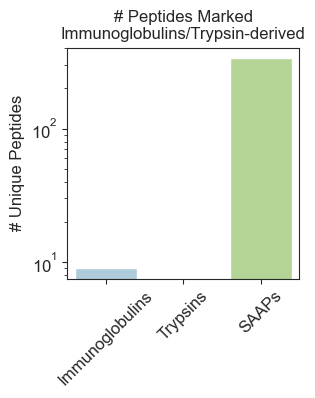

In [292]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(3,3))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Paired',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [293]:
# drop SAAPs that map to no NAMED protein (blank gene AND blank description), then drop the
# immunoglobulin and trypsin contaminants. This removes contaminant-only / unnamed hits.
n0 = len(SAAP_quant_df)
# unnamed = (SAAP_quant_df['Source_gene'] == '') & (SAAP_quant_df['Source_protein'] == '')
unnamed = (SAAP_quant_df['Source_gene'] == '')
print(f"\n{unnamed.sum():,} SAAP observations map to no named protein — dropped")
drop_mask = unnamed | (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)
print(f'{n0:,} -> {len(SAAP_quant_df):,} SAAP observations retained '
      f'({drop_mask.sum():,} dropped: unnamed + immunoglobulin + trypsin)')


152 SAAP observations map to no named protein — dropped
10,376 -> 10,168 SAAP observations retained (208 dropped: unnamed + immunoglobulin + trypsin)


### c. gnomAD Analysis

In [294]:
# Load in gnomAD data (run on Explorer cluster) for annotation of population AFs 
GNOMAD_DIR = CODE_DIR + 'gnomAD/'
gnomad_annotated = pd.read_csv(GNOMAD_DIR + 'Ping_gnomad_annotated.csv')

n_polymorphism = int(gnomad_annotated['polymorphic'].sum())
print(f'matched to known gnomAD variant: {n_polymorphism}')

matched to known gnomAD variant: 317


       Row Number Dataset         MTP_seq          BP_seq  aa_sub tmt_set  \
0               0   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
1               1   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
2               2   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
3               3   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
4               4   acgb1        SSTPEEPK        SSTPEEVK  V to P      S1   
...           ...     ...             ...             ...     ...     ...   
10163        4014    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
10164        4015    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
10165        4016    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
10166        4017    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   
10167        4018    fcb5  GILAADESCGSIAK  GILAADESTGSIAK  T to C      S5   

       Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  ...  \

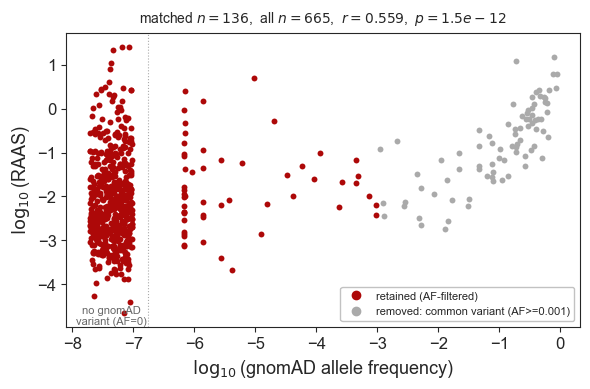

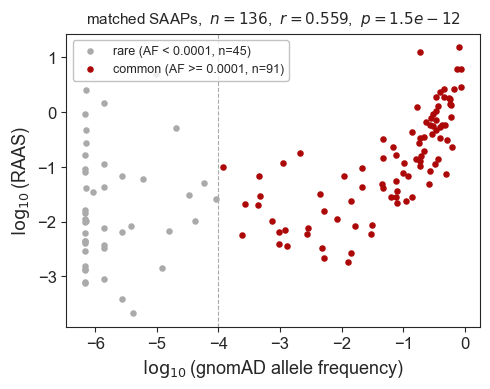

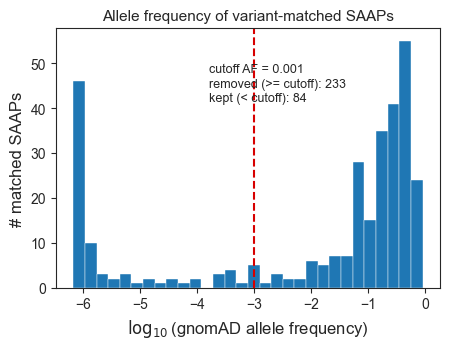

In [295]:
# Append gnomAD outputs to SAAP_quant_df and export to xlsx
gnomad_cols = ['gnomad_status', 'gene', 'protein', 'protein_pos', 'gnomad_variant',
               'gnomad_af', 'gnomad_ac', 'polymorphic', 'reproduces_saap_sub',
               'exact_mutation', 'consequence']
gnomad_merge = (gnomad_annotated
                .rename(columns={'mtp_seq': 'MTP_seq', 'bp_seq': 'BP_seq'})
                [['MTP_seq', 'BP_seq'] + gnomad_cols]
                .sort_values('gnomad_af', na_position='last')          # keep variant-matched row per SAAP
                .drop_duplicates(['MTP_seq', 'BP_seq'], keep='first'))
SAAP_quant_df = SAAP_quant_df.merge(gnomad_merge, on=['MTP_seq', 'BP_seq'], how='left')
print(SAAP_quant_df)

# Save as Supplemental_Data_2.SAAP_precursor_reporter_quant_gnomAD.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_2.SAAP_precursor_reporter_quant_gnomAD.xlsx', sheet_name='Users', index=True)

# gnomAD allele frequency filter
AF_THRESHOLD = 0.001  # 0.01 = common variants filtered out
is_common_variant = SAAP_quant_df['gnomad_af'] >= AF_THRESHOLD
n_rows_before, n_saap_before = len(SAAP_quant_df), SAAP_quant_df['MTP_seq'].nunique()
n_drop = SAAP_quant_df.loc[is_common_variant, 'MTP_seq'].nunique()

SAAP_quant_df_annot = SAAP_quant_df[~is_common_variant].copy()

print(f'AF threshold = {AF_THRESHOLD:g}  (drop SAAPs matching a gnomAD variant with AF >= {AF_THRESHOLD:g})')
print(f'  rows:         {n_rows_before:,} -> {len(SAAP_quant_df_annot):,}')
print(f'  unique SAAPs: {n_saap_before:,} -> '
      f'{SAAP_quant_df_annot["MTP_seq"].nunique():,}  ({n_drop:,} dropped as common variants)')

SAAP_quant_df_annot.to_excel(OUTDIR + f'SAAP_quant_df_AFfiltered_{AF_THRESHOLD:g}.xlsx', index=False)

# Scatter 1 — pooled ACG+FC log10(RAAS) vs log10(gnomAD allele frequency), one point per SAAP.
# Sourced from SAAP_quant_df. ALL SAAPs are shown: variant-matched SAAPs at their real
# allele frequency; SAAPs with no gnomAD variant (no AF) are jittered in a band at the left "AF=0"
# floor so their RAAS still appears. Colored by the AF filter: retained (AF < AF_THRESHOLD)
# -> pink, removed common variant (AF >= AF_THRESHOLD) -> gray. Pearson r/p is over matched SAAPs only.
from matplotlib.lines import Line2D

per = (SAAP_quant_df.replace([np.inf, -np.inf], np.nan)
       .groupby('MTP_seq', as_index=False)
       .agg(mean_RAAS=('Reporter_RAAS', 'mean'), gnomad_af=('gnomad_af', 'max'))
       .dropna(subset=['mean_RAAS']))
per['retained'] = ~(per['gnomad_af'] >= AF_THRESHOLD)               # removed = common variant at/above threshold

matched = per[per['gnomad_af'] > 0].copy()
matched['log_af'] = np.log10(matched['gnomad_af'])
nomatch = per[~(per['gnomad_af'] > 0)].copy()                       # no AF (no matched variant)
floor_x = matched['log_af'].min() - 1.2                             # left "AF = 0" band
nomatch['log_af'] = floor_x + np.random.default_rng(0).uniform(-0.35, 0.35, len(nomatch))

r_val, p_val = sp.stats.pearsonr(matched['log_af'], matched['mean_RAAS'])   # over matched only

fig, ax = plt.subplots(figsize=(6, 4))
for d in (nomatch, matched):
    g, k = d[~d['retained']], d[d['retained']]
    ax.scatter(g['log_af'], g['mean_RAAS'], c='#aaaaaa', s=18, linewidths=0, zorder=2)
    ax.scatter(k['log_af'], k['mean_RAAS'], c="#ad0808", s=18, linewidths=0, zorder=3)
ax.axvline(floor_x + 0.6, color='#aaaaaa', ls=':', lw=0.8)             # separates the no-variant band
ax.annotate('no gnomAD\nvariant (AF=0)', (floor_x, ax.get_ylim()[0]), ha='center', va='bottom',
            fontsize=8, color='0.4')
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=13)
ax.set_ylabel(r'$\log_{10}$(RAAS)', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.text(0.5, 1.02, rf'matched $n={len(matched)}$,  all $n={len(per)}$,  $r={r_val:.3f}$,  $p={p_val:.1e}$',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10)
ax.legend(handles=[Line2D([], [], marker='o', ls='', c='#ad0808', label='retained (AF-filtered)'),
                   Line2D([], [], marker='o', ls='', c='#aaaaaa', label=f'removed: common variant (AF>={AF_THRESHOLD:g})')],
          loc='lower right', frameon=True, facecolor='white', edgecolor='0.7', fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'QC_SAAP_RAAS_vs_gnomAD_AF_scatter.pdf', bbox_inches='tight'); plt.show()

# Scatter 2 — same axes, restricted to variant-matched SAAPs, colored by allele-frequency class:
# pink = common variant (AF >= AF_COMMON), gray = rare (AF < AF_COMMON). Works on the current data
# (all matched SAAPs already carry an allele frequency).
AF_COMMON = 1e-4   # common-vs-rare allele-frequency cutoff

raas_per_saap = (SAAP_quant_df.replace([np.inf, -np.inf], np.nan)
                 .groupby('MTP_seq', as_index=False)['Reporter_RAAS'].mean()
                 .rename(columns={'Reporter_RAAS': 'mean_RAAS'}))
m = (gnomad_annotated.loc[gnomad_annotated['gnomad_af'] > 0, ['mtp_seq', 'gnomad_af']]
     .rename(columns={'mtp_seq': 'MTP_seq'})
     .drop_duplicates('MTP_seq')
     .merge(raas_per_saap, on='MTP_seq', how='inner')
     .dropna(subset=['gnomad_af', 'mean_RAAS']))
m['log_af'] = np.log10(m['gnomad_af'])
m['common'] = m['gnomad_af'] >= AF_COMMON

x, y = m['log_af'].to_numpy(), m['mean_RAAS'].to_numpy()
r_val, p_val = sp.stats.pearsonr(x, y); n_val = len(x)

fig, ax = plt.subplots(figsize=(5, 4))
rare, common = m[~m['common']], m[m['common']]
ax.scatter(rare['log_af'], rare['mean_RAAS'], c='#aaaaaa', s=22, linewidths=0, zorder=2,
           label=f'rare (AF < {AF_COMMON:g}, n={len(rare)})')
ax.scatter(common['log_af'], common['mean_RAAS'], c='#ad0808', s=22, linewidths=0, zorder=3,
           label=f'common (AF >= {AF_COMMON:g}, n={len(common)})')
ax.axvline(np.log10(AF_COMMON), color='#aaaaaa', ls='--', lw=0.8)
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=13)
ax.set_ylabel(r'$\log_{10}$(RAAS)', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.text(0.5, 1.02, rf'matched SAAPs,  $n={n_val}$,  $r={r_val:.3f}$,  $p={p_val:.1e}$',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='0.7', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'QC_SAAP_RAAS_vs_gnomAD_AF_scatter_byAFclass.pdf', bbox_inches='tight'); plt.show()

af = gnomad_annotated.loc[gnomad_annotated['gnomad_af'] > 0, 'gnomad_af'].dropna()
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.hist(np.log10(af), bins=30, color=colors[0], edgecolor='white', linewidth=0.3)
ax.axvline(np.log10(AF_THRESHOLD), ls='--', color="#D70000", lw=1.5)
n_rm = int((af >= AF_THRESHOLD).sum())
ax.annotate(f'cutoff AF = {AF_THRESHOLD:g}\nremoved (>= cutoff): {n_rm}\nkept (< cutoff): {len(af) - n_rm}',
            (0.4, 0.72), xycoords='axes fraction', fontsize=9)
ax.set_xlabel(r'$\log_{10}$(gnomAD allele frequency)', fontsize=12); ax.set_ylabel('# matched SAAPs', fontsize=12)
ax.set_title('Allele frequency of variant-matched SAAPs', fontsize=11)
plt.tight_layout(); plt.savefig(PLOT_DIR + 'QC_gnomAD_AF_distribution.pdf', bbox_inches='tight'); plt.show()

In [296]:
# Make sure gnomAD filtering has been applied
print(len(SAAP_quant_df_annot))
print(len(SAAP_quant_df))
SAAP_quant_df = SAAP_quant_df_annot 

8336
10168


# 1. SAAP Detection & QC

## 1a Dataset Metrics

In [297]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 600x500 with 0 Axes>

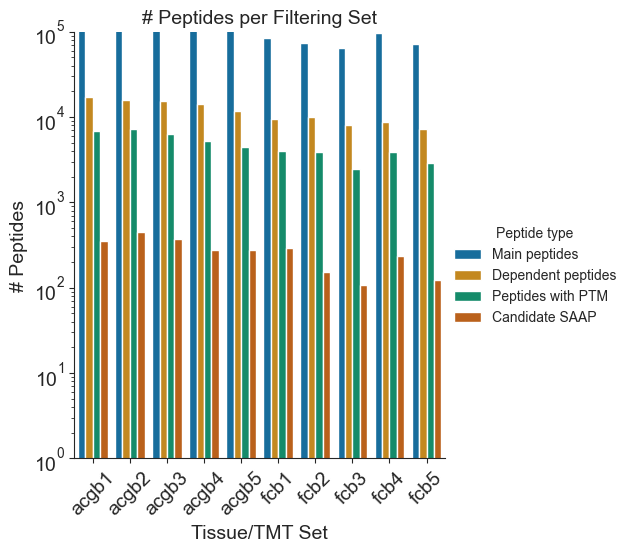

In [298]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(6,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1)

ax.set(yscale='log', ylim=(1, 1e5))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

### Percentage of candidate SAAPs validated through database search

In [299]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

acgb1
acgb2
acgb3
acgb4
acgb5
fcb1
fcb2
fcb3
fcb4
fcb5


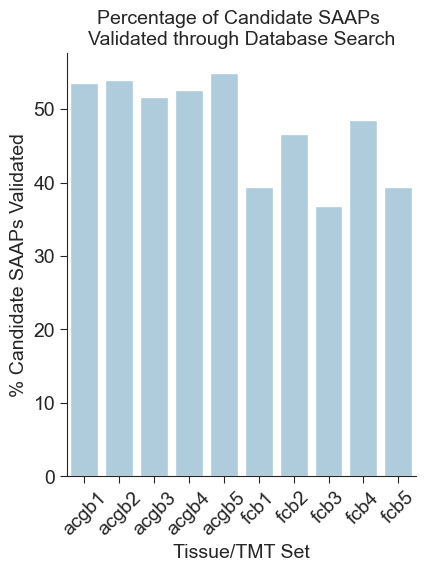

In [300]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='Paired')
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14)
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

## 1b Validation Metrics

### Retention time and spectra prediction (MSBooster)

In [301]:
"""
Localization rescue of SAAPs using MSBooster spectral entropy and RT agreement.

A SAAP's positional probability is only high when the MS2 spectrum has the b/y ions
flanking the substituted residue. Low-abundance or poorly-fragmenting peptides often
lack those ions, so a real SAAP can score low purely from missing fragments. A hard
positional-probability cut therefore discards genuine SAAPs.

To recover them we use two orthogonal MSBooster scores from the *_edited.pin files:

  weighted_spectral_entropy : how well the observed spectrum matches the predicted
                              spectrum for the assigned SAAP (higher = better).
  delta_RT_loess            : difference between observed and predicted retention
                              time, loess-calibrated and already absolute
                              (lower = better). Orthogonal to spectral matching.

Both thresholds are calibrated against DECOYS. Each pin row has Label = 1 (target) or
-1 (decoy). We set each threshold to admit a chosen small fraction of decoys
(DECOY_ADMIT), giving every cutoff a known decoy-admission rate rather than an
arbitrary number.

Rule: keep a SAAP if it is confidently localized (positional probability >= cut),
OR if it is uncertainly localized but passes BOTH the entropy and RT thresholds.

Note: the entropy score is one-sided (it only checks the SAAP matches itself), so it
cannot reject an isobaric substitution like I<->L where the SAAP and base peptide give
the same spectrum. Those land at RAAS ~ 0; the check at the end reports how many
rescued SAAPs fall there.

Requires:
  - SAAP_quant_df with 'Positional_probability' and (per-SAAP, joined upstream)
    'spectral_entropy' and 'delta_RT' columns;
  - the *_edited.pin files, used here only to calibrate thresholds from decoys.
"""

POS_PROB_CUT = 0.9     # localization-confidence cut
DECOY_ADMIT  = 0.05    # fraction of decoys each threshold is allowed to admit (5%)

# ---- calibrate thresholds from decoys across all plex pins --------------------
# Pool every _edited.pin (all plexes), split by Label, and set:
#   entropy threshold = value admitting DECOY_ADMIT of decoys from the top (high=good)
#   RT threshold      = value admitting DECOY_ADMIT of decoys from the bottom (low=good)
ent_decoy, rt_decoy = [], []
for mq_dir in mq_dir_list:
    for f in glob(mq_dir + '*_edited.pin'):
        cols = ['Label', 'weighted_spectral_entropy', 'delta_RT_loess']
        d = pd.read_csv(f, sep='\t', usecols=cols, low_memory=False)
        dec = d[d['Label'] == -1]
        ent_decoy.append(dec['weighted_spectral_entropy'].values)
        rt_decoy.append(dec['delta_RT_loess'].values)
ent_decoy = np.concatenate(ent_decoy)
rt_decoy  = np.concatenate(rt_decoy)

ENTROPY_THRESHOLD = np.nanpercentile(ent_decoy, 100 * (1 - DECOY_ADMIT))  # high = good
RT_THRESHOLD      = np.nanpercentile(rt_decoy,  100 * DECOY_ADMIT)        # low  = good
print(f'Decoy-calibrated thresholds (admit {DECOY_ADMIT:.0%} of decoys):')
print(f'  weighted_spectral_entropy >= {ENTROPY_THRESHOLD:.4f}')
print(f'  delta_RT_loess            <= {RT_THRESHOLD:.4f}')

# ---- apply the rescue gate ----------------------------------------------------
pp  = SAAP_quant_df['Positional_probability']
ent = SAAP_quant_df['spectral_entropy']     # weighted_spectral_entropy, joined upstream
rt  = SAAP_quant_df['delta_RT']             # delta_RT_loess, joined upstream

pass_localization = pp >= POS_PROB_CUT
rescued = (pp < POS_PROB_CUT) & (ent >= ENTROPY_THRESHOLD) & (rt <= RT_THRESHOLD)

SAAP_quant_df['localization_pass'] = pass_localization
SAAP_quant_df['entropy_rescued']   = rescued
SAAP_quant_df['keep_localization'] = pass_localization | rescued

# ---- report what the rescue changed -------------------------------------------
n_total = len(SAAP_quant_df)
n_kept  = int(SAAP_quant_df['keep_localization'].sum())
print(f'passed positional prob >= {POS_PROB_CUT}: {int(pass_localization.sum()):,}')
print(f'rescued (entropy AND RT):         {int(rescued.sum()):,}')
print(f'total kept:                       {n_kept:,} of {n_total:,} ({n_kept/n_total:.1%})')
print(f'dropped:                          {n_total - n_kept:,}')

# ---- check whether rescued SAAPs pile up at RAAS ~ 0 (isobaric artifacts) ------
for col in ['Reporter_RAAS', 'Prec_RAAS']:
    if col in SAAP_quant_df.columns:
        r = pd.to_numeric(SAAP_quant_df.loc[rescued, col], errors='coerce').dropna()
        if len(r):
            print(f'rescued {col} within |RAAS|<0.15: {(r.abs() < 0.15).mean():.1%}')

# Apply filtering
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['keep_localization']].reset_index(drop=True)
print(f'filtered SAAP_quant_df: {len(SAAP_quant_df):,} rows retained')

Decoy-calibrated thresholds (admit 5% of decoys):
  weighted_spectral_entropy >= 1.1971
  delta_RT_loess            <= 3.2502
passed positional prob >= 0.9: 2,520
rescued (entropy AND RT):         1,832
total kept:                       4,352 of 8,336 (52.2%)
dropped:                          3,984
rescued Reporter_RAAS within |RAAS|<0.15: 1.1%
rescued Prec_RAAS within |RAAS|<0.15: 0.9%
filtered SAAP_quant_df: 4,352 rows retained


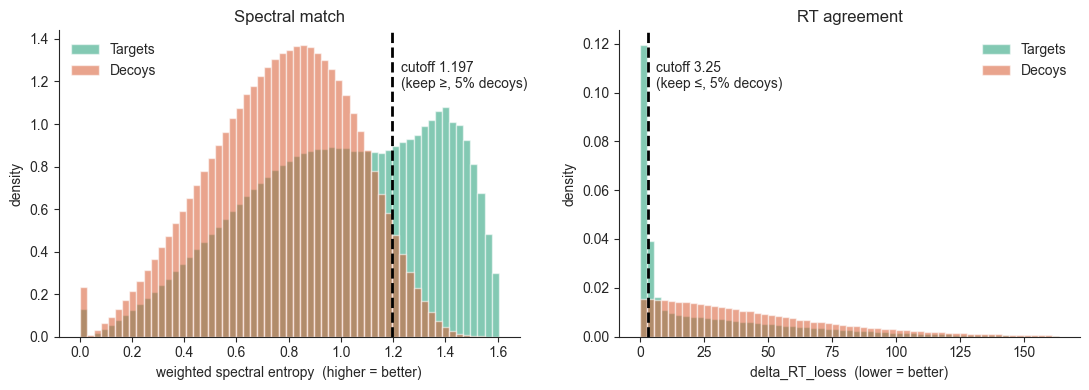

entropy >= 1.197: keeps 35.7% targets, 5.0% decoys
delta_RT <= 3.25:  keeps 35.8% targets, 5.0% decoys


In [302]:
"""
Visualize the decoy-calibrated rescue thresholds.

Pools all *_edited.pin rows across plexes, splits target (Label=1) vs decoy (Label=-1),
and plots the two rescue features with the cutoff that admits DECOY_ADMIT of decoys:

  weighted_spectral_entropy : keep if >= threshold (higher = better spectral match)
  delta_RT_loess            : keep if <= threshold (lower = better RT agreement)

The point of each panel: targets separate from decoys, and the cutoff is placed where
only DECOY_ADMIT (e.g. 5%) of decoys remain on the 'keep' side.
"""

DECOY_ADMIT = 0.05

# ---- pool target/decoy feature values across all plex pins ----
ent_t, ent_d, rt_t, rt_d = [], [], [], []
for mq_dir in mq_dir_list:
    for f in glob(mq_dir + '*_edited.pin'):
        d = pd.read_csv(f, sep='\t',
                        usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'],
                        low_memory=False)
        t   = d[d['Label'] == 1]
        dec = d[d['Label'] == -1]
        ent_t.append(t['weighted_spectral_entropy'].values)
        ent_d.append(dec['weighted_spectral_entropy'].values)
        rt_t.append(t['delta_RT_loess'].values)
        rt_d.append(dec['delta_RT_loess'].values)
ent_t = np.concatenate(ent_t); ent_d = np.concatenate(ent_d)
rt_t  = np.concatenate(rt_t);  rt_d  = np.concatenate(rt_d)

# ---- decoy-calibrated thresholds ----
ent_thr = np.nanpercentile(ent_d, 100 * (1 - DECOY_ADMIT))  # high = good
rt_thr  = np.nanpercentile(rt_d,  100 * DECOY_ADMIT)         # low  = good

# ---- plot ----
T_COLOR, D_COLOR = '#1D9E75', '#D85A30'   # target green, decoy coral
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# entropy panel
ax = axes[0]
bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
ax.hist(ent_t, bins=bins, density=True, color=T_COLOR, alpha=0.55, label='Targets')
ax.hist(ent_d, bins=bins, density=True, color=D_COLOR, alpha=0.55, label='Decoys')
ax.axvline(ent_thr, color='k', ls='--', lw=2)
ax.annotate(f'cutoff {ent_thr:.3f}\n(keep \u2265, {DECOY_ADMIT:.0%} decoys)',
            xy=(ent_thr, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel('weighted spectral entropy  (higher = better)')
ax.set_ylabel('density')
ax.set_title('Spectral match')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# RT panel
ax = axes[1]
bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
ax.hist(rt_t, bins=bins, density=True, color=T_COLOR, alpha=0.55, label='Targets')
ax.hist(rt_d, bins=bins, density=True, color=D_COLOR, alpha=0.55, label='Decoys')
ax.axvline(rt_thr, color='k', ls='--', lw=2)
ax.annotate(f'cutoff {rt_thr:.2f}\n(keep \u2264, {DECOY_ADMIT:.0%} decoys)',
            xy=(rt_thr, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel('delta_RT_loess  (lower = better)')
ax.set_ylabel('density')
ax.set_title('RT agreement')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'rescue_threshold_target_decoy.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'rescue_threshold_target_decoy.png', dpi=300, bbox_inches='tight')
plt.show()

# report keep-rates at these thresholds
print(f'entropy >= {ent_thr:.3f}: keeps {(ent_t>=ent_thr).mean():.1%} targets, {(ent_d>=ent_thr).mean():.1%} decoys')
print(f'delta_RT <= {rt_thr:.2f}:  keeps {(rt_t<=rt_thr).mean():.1%} targets, {(rt_d<=rt_thr).mean():.1%} decoys')

### Positional probability filtering

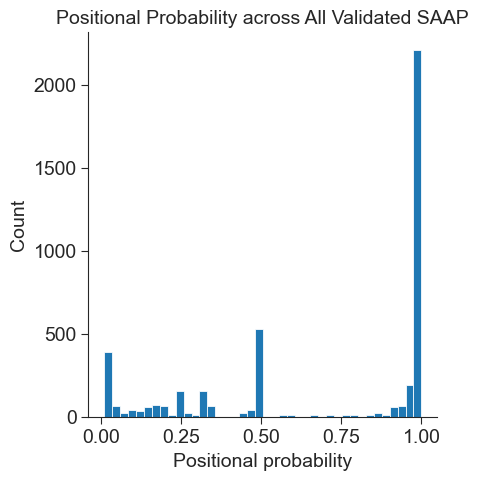

In [ ]:
# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

4352
4352


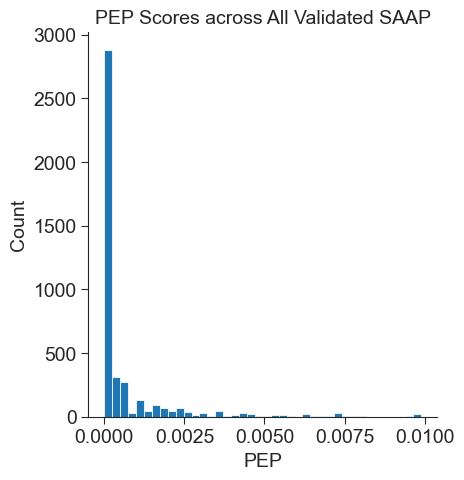

In [ ]:
# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

In [305]:
# Save as Supplemental_Data_2.SAAP_precursor_reporter_quant_neurodegenerative_highConfidence.xlsx
SAAP_quant_df.to_excel(SUPP_DIR + 'Supplemental_Data_2.SAAP_precursor_reporter_quant_neurodegenerative_HighConfidence.xlsx',sheet_name='Users',index=True)

### Fragment ion support at substitution site

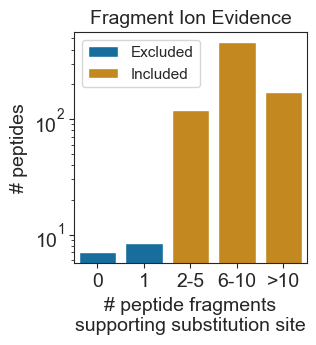

In [323]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = frag_df
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind', errorbar=None)
ax.tick_params('both', labelsize=14)
plt.yscale('log')
plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

### PEP scores and q values

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/1426888465.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/1426888465.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/1426888465.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/1426888465.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


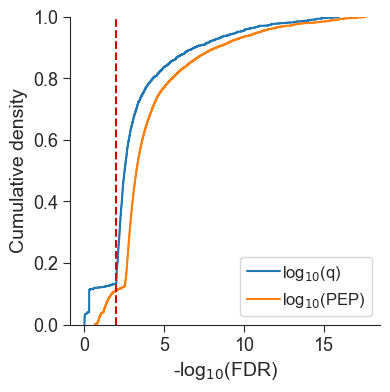

In [307]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.png',dpi=600, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/2872710814.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/2872710814.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/2872710814.py:58: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = hi

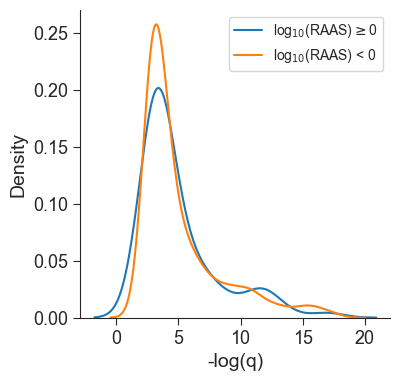

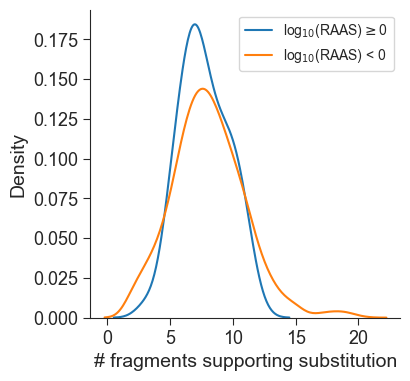

In [308]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log(q)', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.png', dpi=600, bbox_inches='tight')


# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.png',dpi=600, bbox_inches='tight')

### Mass errors for SAAPs and main peptides

In [309]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

acgb1 S1 rows: 624
       MTP_seq  Reporter_RAAS
0  ASSSSLSMDEK      -2.674941
1  ASSSSLSMDEK      -2.662061
2  ASSSSLSMDEK      -2.636868
3  ASSSSLSMDEK      -2.653557
4  ASSSSLSMDEK      -2.718330
High SAAP: ['QVTSTASTFVK', 'QVTSTASTFVK', 'QVTSTASTFVK', 'LYCPYQNIK', 'GPSGPQGPR', 'GPSGPQGPR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'LAQEGGWGVMVSHR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'FTVGDHSR', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'GLTSIVNEK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'DLTTGYDSSQPNK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'KLEALLASNDNANK', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'ELVDDSLNNVR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'VLMEDDDLYSCVVENPISQGR', 'DSPETEESPAPEPR', 'LLEGEEDR'

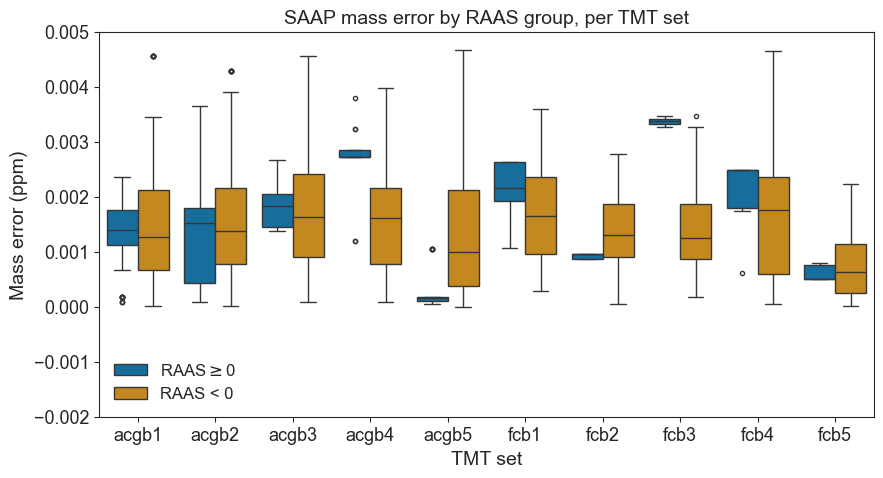

In [310]:
# mass error analysis
SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{ds} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[ds]['High RAAS mass error']  = mass_err_dict[ds]['High RAAS mass error'] + high_errs
            mass_err_dict[ds]['Low RAAS mass error']  = mass_err_dict[ds]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

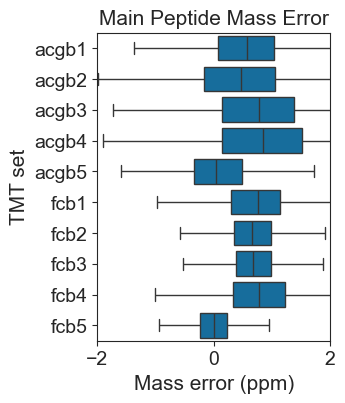

In [311]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[ds]['Main peptide mass error'] = mass_err_dict[ds]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

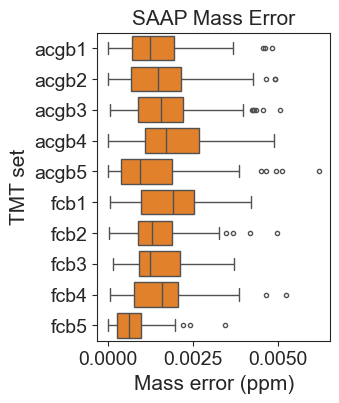

In [312]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[ds]['SAAP mass error'] = mass_err_dict[ds]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

### N SAAPs post-filtering/validation

In [313]:
def simplify_dataset(x):
    if x.startswith('acg'):
        return 'acg'
    elif x.startswith('fc'):
        return 'fc'
    return x

SAAP_quant_df_grouped = SAAP_quant_df.copy()
SAAP_quant_df_grouped['Dataset'] = SAAP_quant_df_grouped['Dataset'].apply(simplify_dataset)

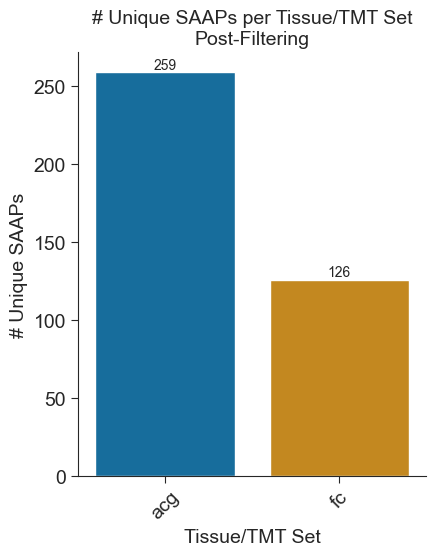

In [314]:
# N SAAPs per dataset post-filtering by brain region 
datasets = ['acg', 'fc']
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df_grouped[SAAP_quant_df_grouped['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_brainregion.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_brainregion.png',dpi=600,bbox_inches='tight')


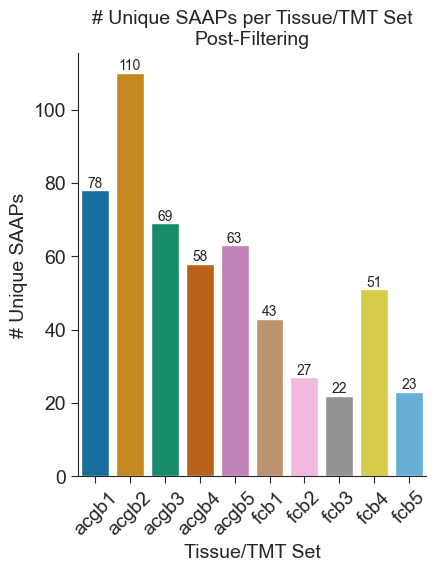

In [315]:
# N SAAPs per dataset post-filtering by tmt set 
datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb1', 'fcb2', 'fcb3', 'fcb4', 'fcb5']
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_tmtset.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering_tmtset.png',dpi=600,bbox_inches='tight')

# 2. RAAS

## 2a Global Metrics

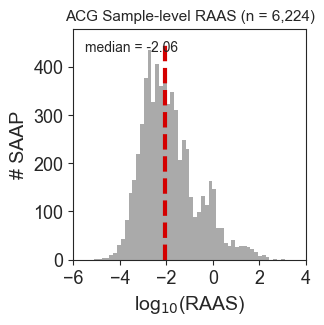

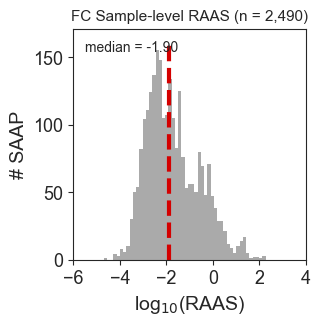

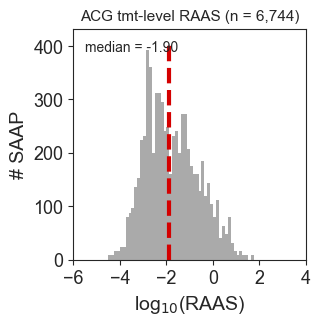

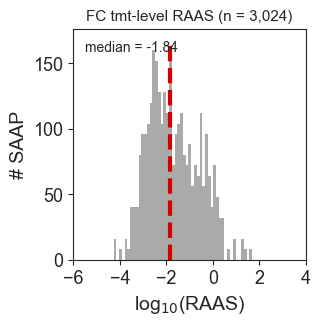

In [329]:
# Global RAAS distributions — all SAAP observations pooled within each tissue.
# Reporter-ion (sample-level) and precursor-ion (TMT-level) RAAS; one panel per tissue.
for col, fstub in [('Reporter_RAAS', 'Sample'), ('Prec_RAAS', 'tmt')]:
    for tissue_df, tcolor, tname in [(SAAP_quant_df_acg, '#aaaaaa', 'acg'), (SAAP_quant_df_fc, '#aaaaaa', 'fc')]:
        ratios = [x for x in tissue_df[col].values if ~np.isnan(x) and ~np.isinf(x)]
        fig, ax = plt.subplots(figsize=(3, 3))
        sns.histplot(ratios, color=tcolor, bins=50, linewidth=0, alpha=1)
        med = np.median(ratios)
        ax.plot((med, med), plt.ylim(), '--', color='#d40000', linewidth=3)
        ax.annotate(f'median = {med:.2f}', (0.05, 0.9), xycoords='axes fraction', fontsize=10)
        ax.set_ylabel('# SAAP', fontsize=14); ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
        ax.tick_params('both', labelsize=13); ax.set_xticks([-6, -4, -2, 0, 2, 4])
        ax.set_title(f'{tname.upper()} {fstub}-level RAAS (n = {len(ratios):,})', fontsize=11)
        plt.savefig(f'{PLOT_DIR}{fstub}_level_RAAS_allDS_onehistplot_{tname}.pdf', bbox_inches='tight')
        plt.show()


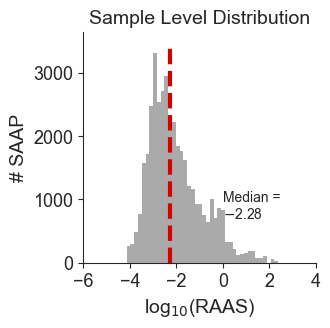

In [333]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, bins=40, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4])
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

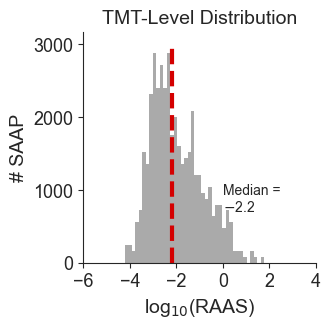

In [332]:
# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, bins=40, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4])
ax.set_title(r'TMT-Level Distribution',fontsize=14)
sns.despine()

plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.png', dpi=600, bbox_inches='tight')

## 2b Precursor and Reporter RAAS Agreeability

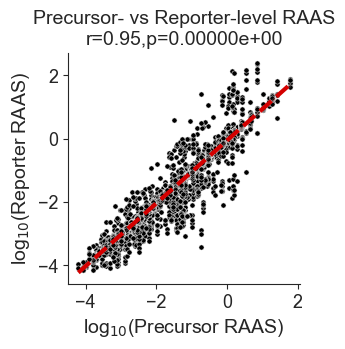

In [319]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color="#000000",edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

## 2c TMTset-level RAAS Distributions

In [320]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=10, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

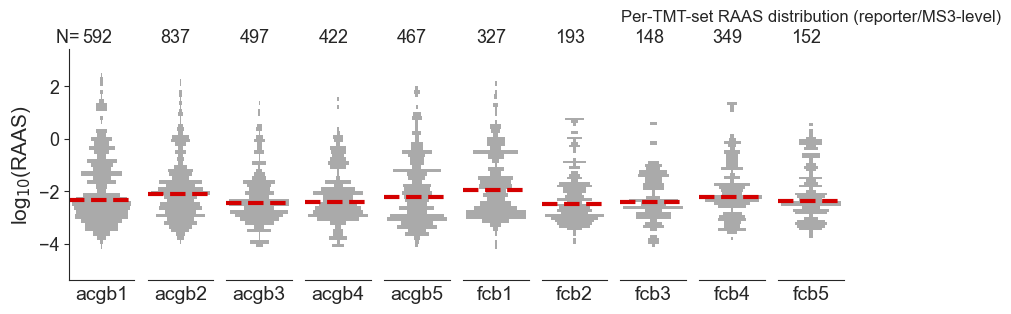

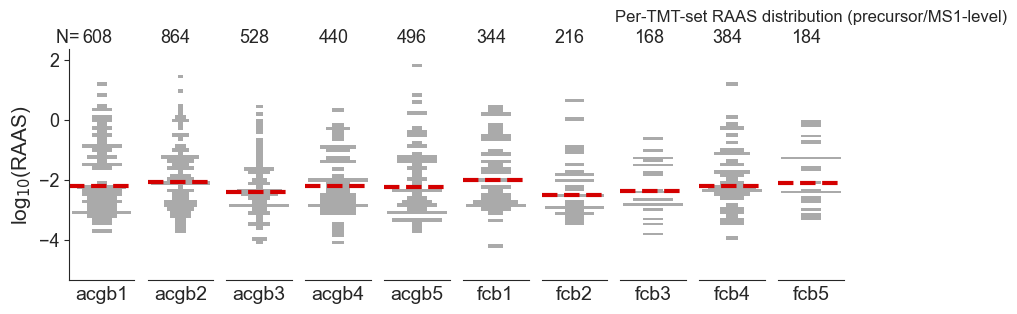

In [334]:
# Per-dataset RAAS distributions (one violin per TMT set), reporter- and precursor-ion levels.
# N = number of quantified SAAP ratios per dataset; datasets ordered ACG (b1-5) then FC (b2-5).
for col, fname in [('Reporter_RAAS', 'sample_level_RAAS_allDS_nogrid.pdf'),
                   ('Prec_RAAS', 'TMT_level_RAAS_allDS_nogrid.pdf')]:
    fig, axes = plt.subplots(1, len(datasets), figsize=(len(datasets), 3), sharey=True)
    for ax in axes:
        ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
        ax.tick_params('x', bottom=False, labelbottom=False)
        if ax is not axes[0]:
            ax.spines['left'].set_visible(False); ax.tick_params(left=False)
    for i, ds in enumerate(datasets):
        axes[i].set_xlabel(ds, fontsize=14)
        vals = [x for x in SAAP_quant_df.loc[SAAP_quant_df['Dataset'] == ds, col].values
                if ~np.isnan(x) and ~np.isinf(x)]
        bihist(vals, vals, nbins=50, h=axes[i], color='#aaaaaa')
        if i == 0:
            axes[i].annotate('N= ', (-0.2, 1.03), xycoords='axes fraction', fontsize=13)
        axes[i].annotate(f'{len(vals):,}', (0.2, 1.03), xycoords='axes fraction', fontsize=13)
        axes[i].plot(axes[i].get_xlim(), (np.median(vals), np.median(vals)), '--', color='#d40000', linewidth=3)
    axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15); axes[0].tick_params('y', labelsize=13)
    plt.title(f"Per-TMT-set RAAS distribution ({'reporter/MS3' if col=='Reporter_RAAS' else 'precursor/MS1'}-level)", fontsize=12,pad=20)
    plt.savefig(PLOT_DIR + fname, bbox_inches='tight'); plt.show()


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_21638/1753279990.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


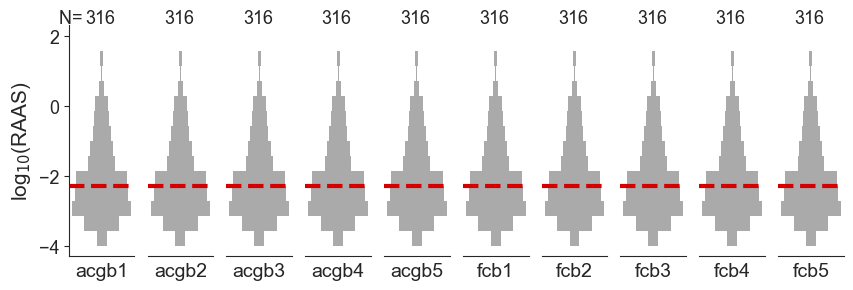

In [328]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

# 3. RAAS Changes Associated with Neurodegeneration

## 3a Data pre-processing

## 3b RAAS fold change distributions

## 3c Per-SAAP pairwise RAAS significance with neurodegeneration

### Assumption Diagnostics

### Normality and variance diagnostics for RAAS values across age groups
##### Goal: test whether RAAS changes across age groups
##### Questions: is the data normally distributed? Is the variance equal across groups? 

### Is the within-group variance of RAAS the same across 4 disease groups? 

### What are the significant SAAP-level changes with disease within brain regions?

### What are the significant SAAP-level changes with disease globally?

# Relative RAAS computed for shared SAAP between 2 patients